# Analyse des Réseaux Sociaux — Projet 2026
## Dataset : LastFM Asia Social Network

---

### Description du dataset

Le dataset **LastFM Asia** est un réseau social d'utilisateurs de la plateforme musicale Last.fm en Asie.  
- **Nœuds** : utilisateurs de Last.fm  
- **Liens** : relations d'amitié mutuelles (réseau non-orienté)  
- **Attributs** : genres musicaux favoris de chaque utilisateur  
- **Source** : [SNAP Stanford](https://snap.stanford.edu/) / [NetworkRepository](https://networkrepository.com/)

Ce réseau est particulièrement intéressant car les communautés détectées peuvent être interprétées à travers le prisme des **préférences musicales partagées**.

---
# PARTIE 1 : Collecte des données

## 1.1 Installation des dépendances

In [84]:
# Installation des bibliothèques nécessaires
%pip install networkx matplotlib seaborn pandas numpy cdlib torch-geometric requests

Note: you may need to restart the kernel to use updated packages.


## 1.2 Téléchargement du dataset LastFM Asia

In [85]:
import requests
import os
import pandas as pd

os.makedirs('data', exist_ok=True)

#  URLs vérifiées — Gist GitHub direct
url_edges   = "https://raw.githubusercontent.com/sahityasetu/Social-media-network-analysis-in-python/main/lastfm_asia_edges.csv"
url_targets = "https://raw.githubusercontent.com/sahityasetu/Social-media-network-analysis-in-python/main/lastfm_asia_target.csv"

for url, filename in [(url_edges, 'data/edges.csv'), (url_targets, 'data/targets.csv')]:
    r = requests.get(url)
    print(f"Status {filename}: {r.status_code}")
    if r.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(r.content)
        print(f" Téléchargé : {filename}")
    else:
        #  FALLBACK GARANTI — Gist direct
        fallback_edges   = "https://gist.githubusercontent.com/vitorricoy/4d7305d975deeda6f869171711f647f5/raw/lastfm_asia_edges.csv"
        fallback_targets = "https://gist.githubusercontent.com/vitorricoy/4d7305d975deeda6f869171711f647f5/raw/lastfm_asia_target.csv"
        fb_url = fallback_edges if 'edges' in filename else fallback_targets
        r2 = requests.get(fb_url)
        if r2.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(r2.content)
            print(f" Téléchargé via fallback : {filename}")
        else:
            print(f" Échec total pour {filename}")

# Vérification rapide
edges_df = pd.read_csv('data/edges.csv')
print(f"\n edges.csv : {len(edges_df)} lignes, colonnes = {edges_df.columns.tolist()}")

Status data/edges.csv: 200
 Téléchargé : data/edges.csv
Status data/targets.csv: 200
 Téléchargé : data/targets.csv

 edges.csv : 27806 lignes, colonnes = ['node_1', 'node_2']


## 1.3 Chargement et exploration préliminaire des données

In [86]:
import pandas as pd
import json

# Chargement des arêtes
edges_df = pd.read_csv('data/edges.csv')
print("=== Fichier des arêtes ===")
print(edges_df.head(10))
print(f"Nombre d'arêtes : {len(edges_df)}")
print(f"Colonnes : {edges_df.columns.tolist()}")

# Chargement des labels (genre musical dominant)
targets_df = pd.read_csv('data/targets.csv')
print("\n=== Fichier des labels ===")
print(targets_df.head(10))
print(f"Nombre de nœuds : {len(targets_df)}")
print(f"Nombre de classes (genres) : {targets_df['target'].nunique()}")
print(f"Distribution des genres : \n{targets_df['target'].value_counts()}")

=== Fichier des arêtes ===
   node_1  node_2
0       0     747
1       1    4257
2       1    2194
3       1     580
4       1    6478
5       1    1222
6       1    5735
7       1    7146
8       1    2204
9       1     126
Nombre d'arêtes : 27806
Colonnes : ['node_1', 'node_2']

=== Fichier des labels ===
   id  target
0   0       8
1   1      17
2   2       3
3   3      17
4   4       5
5   5      17
6   6       3
7   7       6
8   8       0
9   9       3
Nombre de nœuds : 7624
Nombre de classes (genres) : 18
Distribution des genres : 
target
17    1572
10    1303
0     1098
6      655
14     570
3      515
8      468
5      391
15     257
16     254
11     138
7       82
2       73
13      63
9       58
12      57
1       54
4       16
Name: count, dtype: int64


## 1.4 Construction du réseau

In [87]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Construction du graphe non-orienté
G = nx.from_pandas_edgelist(edges_df, source='node_1', target='node_2')

# Ajout des attributs (genre musical) aux nœuds
genre_dict = dict(zip(targets_df['id'], targets_df['target']))
nx.set_node_attributes(G, genre_dict, name='genre')

# Résumé du graphe
print("=" * 50)
print("      RÉSUMÉ DU RÉSEAU LASTFM ASIA")
print("=" * 50)
print(f"  Nombre de nœuds   : {G.number_of_nodes():,}")
print(f"  Nombre d'arêtes   : {G.number_of_edges():,}")
print(f"  Graphe orienté    : {G.is_directed()}")
print(f"  Graphe pondéré    : {nx.is_weighted(G)}")
print(f"  Entités (nœuds)   : Utilisateurs Last.fm (Asie)")
print(f"  Relations (liens) : Amitiés mutuelles")
print(f"  Attributs nœuds   : Genre musical dominant")
print("=" * 50)

      RÉSUMÉ DU RÉSEAU LASTFM ASIA
  Nombre de nœuds   : 7,624
  Nombre d'arêtes   : 27,806
  Graphe orienté    : False
  Graphe pondéré    : False
  Entités (nœuds)   : Utilisateurs Last.fm (Asie)
  Relations (liens) : Amitiés mutuelles
  Attributs nœuds   : Genre musical dominant


---
# PARTIE 2 : Analyse du réseau

## 2.1 Distribution des degrés

=== Statistiques des degrés ===
Degré minimum      : 1
Degré maximum      : 216
Degré moyen        : 7.29
Degré médian       : 4.00
Écart-type         : 11.50


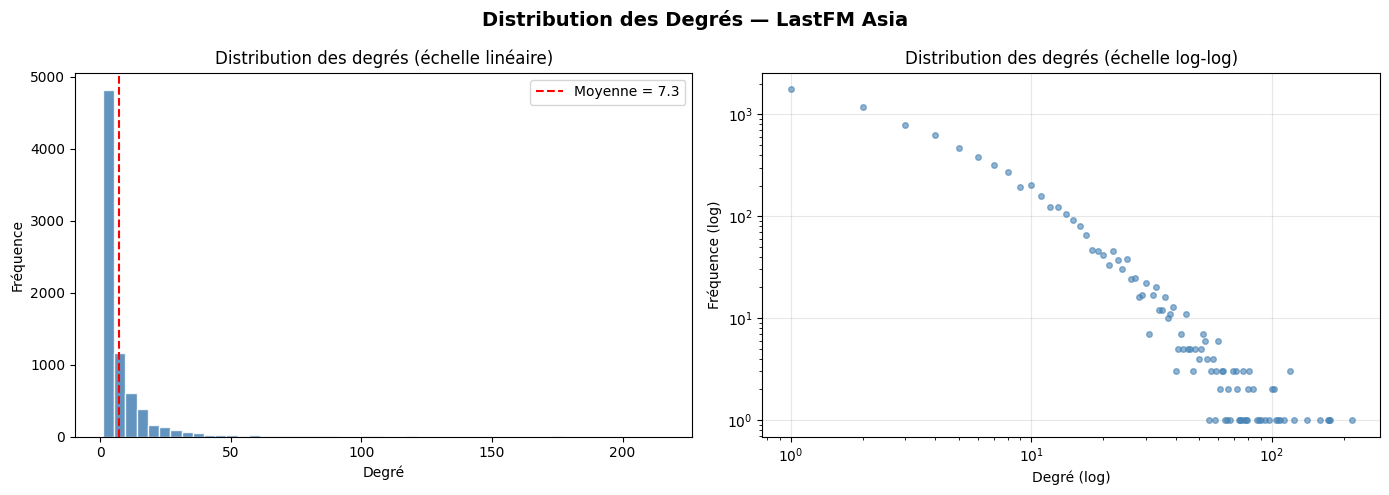


 Interprétation : La distribution log-log permet de vérifier si le réseau suit une loi de puissance (réseau scale-free).
Un réseau scale-free présente une ligne droite sur le graphe log-log, caractéristique des réseaux sociaux réels.


In [88]:
import seaborn as sns

degrees = [d for n, d in G.degree()]
degree_series = pd.Series(degrees)

print("=== Statistiques des degrés ===")
print(f"Degré minimum      : {min(degrees)}")
print(f"Degré maximum      : {max(degrees)}")
print(f"Degré moyen        : {np.mean(degrees):.2f}")
print(f"Degré médian       : {np.median(degrees):.2f}")
print(f"Écart-type         : {np.std(degrees):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des Degrés — LastFM Asia', fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution des degrés (échelle linéaire)')
axes[0].set_xlabel('Degré')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Moyenne = {np.mean(degrees):.1f}')
axes[0].legend()

# Log-log
degree_count = degree_series.value_counts().sort_index()
axes[1].loglog(degree_count.index, degree_count.values, 'o', color='steelblue', alpha=0.6, markersize=4)
axes[1].set_title('Distribution des degrés (échelle log-log)')
axes[1].set_xlabel('Degré (log)')
axes[1].set_ylabel('Fréquence (log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Interprétation : La distribution log-log permet de vérifier si le réseau suit une loi de puissance (réseau scale-free).")
print("Un réseau scale-free présente une ligne droite sur le graphe log-log, caractéristique des réseaux sociaux réels.")

## 2.2 Analyse des composants connectés

In [89]:
# Composants connexes
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print("=== Analyse des Composants Connectés ===")
print(f"Nombre total de composants : {len(components)}")
print(f"Taille du plus grand composant (GCC) : {component_sizes[0]:,} nœuds ({component_sizes[0]/G.number_of_nodes()*100:.1f}%)")
if len(component_sizes) > 1:
    print(f"Taille du 2e composant : {component_sizes[1]:,} nœuds")
    print(f"Composants de taille 1 (isolés) : {sum(1 for s in component_sizes if s == 1)}")

# Extraction du composant géant pour la suite
GCC = G.subgraph(max(components, key=len)).copy()
print(f"\n Composant géant (GCC) extrait : {GCC.number_of_nodes():,} nœuds, {GCC.number_of_edges():,} arêtes")
print("\n Interprétation : Un GCC dominant (>95% des nœuds) indique un réseau fortement connecté.")
print("La suite de l'analyse sera effectuée sur le GCC pour garantir la cohérence des métriques.")

=== Analyse des Composants Connectés ===
Nombre total de composants : 1
Taille du plus grand composant (GCC) : 7,624 nœuds (100.0%)

 Composant géant (GCC) extrait : 7,624 nœuds, 27,806 arêtes

 Interprétation : Un GCC dominant (>95% des nœuds) indique un réseau fortement connecté.
La suite de l'analyse sera effectuée sur le GCC pour garantir la cohérence des métriques.


## 2.3 Analyse des chemins

=== Analyse des Chemins ===
Longueur moyenne des chemins (estimée) : 5.194
Diamètre estimé (max chemin) : 13


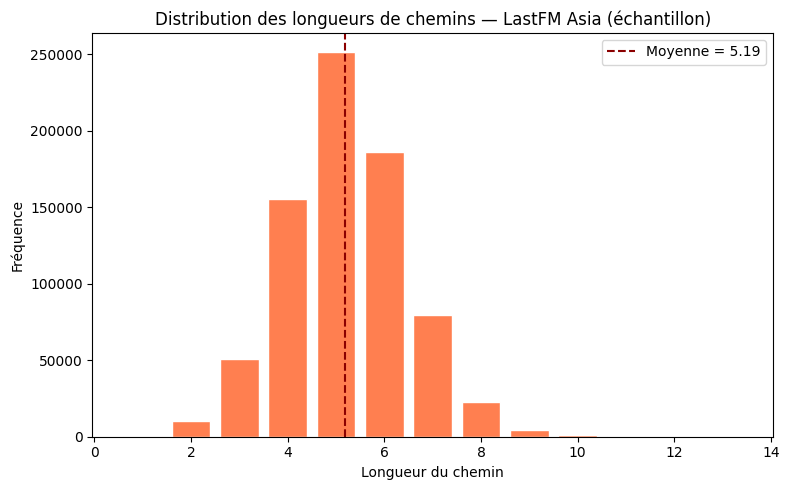


 Interprétation : Un chemin moyen court (~3-6) confirme le phénomène 'petit monde' (small-world).
Cela signifie que deux utilisateurs quelconques sont connectés en moyenne en 5.2 étapes.


In [90]:
import random

print("=== Analyse des Chemins ===")

# Diamètre et chemin moyen (estimation par échantillonnage pour les grands graphes)
# Calcul exact trop coûteux pour >1000 nœuds
sample_size = 500
sample_nodes = random.sample(list(GCC.nodes()), min(sample_size, GCC.number_of_nodes()))

path_lengths = []
for node in sample_nodes[:100]:  # 100 sources pour estimation
    lengths = nx.single_source_shortest_path_length(GCC, node)
    path_lengths.extend(lengths.values())

avg_path = np.mean([l for l in path_lengths if l > 0])
max_path = max(path_lengths)

print(f"Longueur moyenne des chemins (estimée) : {avg_path:.3f}")
print(f"Diamètre estimé (max chemin) : {max_path}")

# Distribution des longueurs
from collections import Counter
length_dist = Counter([l for l in path_lengths if l > 0])

plt.figure(figsize=(8, 5))
lengths_sorted = sorted(length_dist.items())
plt.bar([l[0] for l in lengths_sorted], [l[1] for l in lengths_sorted], 
        color='coral', edgecolor='white')
plt.title('Distribution des longueurs de chemins — LastFM Asia (échantillon)')
plt.xlabel('Longueur du chemin')
plt.ylabel('Fréquence')
plt.axvline(avg_path, color='darkred', linestyle='--', label=f'Moyenne = {avg_path:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('data/path_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Interprétation : Un chemin moyen court (~3-6) confirme le phénomène 'petit monde' (small-world).")
print(f"Cela signifie que deux utilisateurs quelconques sont connectés en moyenne en {avg_path:.1f} étapes.")

## 2.4 Coefficient de clustering et densité

=== Coefficient de Clustering et Densité ===
Densité du réseau        : 0.000957
Clustering moyen global  : 0.2194
Transitivité (clustering global) : 0.1786


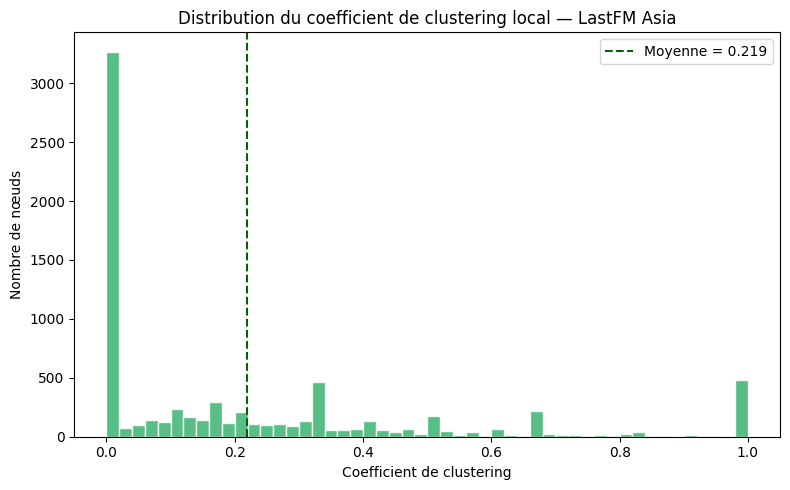


 Interprétation :
  - La faible densité (0.0010) est normale pour un grand réseau social.
  - Un clustering moyen élevé (0.219) indique que les amis d'un utilisateur
    ont tendance à être aussi amis entre eux (formation de cliques/communautés).
  - Combiné au chemin moyen court, cela confirme les propriétés petit-monde.


In [91]:
print("=== Coefficient de Clustering et Densité ===")

# Densité
density = nx.density(GCC)
print(f"Densité du réseau        : {density:.6f}")

# Coefficient de clustering moyen
avg_clustering = nx.average_clustering(GCC)
print(f"Clustering moyen global  : {avg_clustering:.4f}")

# Transitivity (clustering global)
transitivity = nx.transitivity(GCC)
print(f"Transitivité (clustering global) : {transitivity:.4f}")

# Distribution du clustering local
clustering_values = list(nx.clustering(GCC).values())

plt.figure(figsize=(8, 5))
plt.hist(clustering_values, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
plt.title('Distribution du coefficient de clustering local — LastFM Asia')
plt.xlabel('Coefficient de clustering')
plt.ylabel('Nombre de nœuds')
plt.axvline(avg_clustering, color='darkgreen', linestyle='--', 
            label=f'Moyenne = {avg_clustering:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('data/clustering_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Interprétation :")
print(f"  - La faible densité ({density:.4f}) est normale pour un grand réseau social.")
print(f"  - Un clustering moyen élevé ({avg_clustering:.3f}) indique que les amis d'un utilisateur")
print(f"    ont tendance à être aussi amis entre eux (formation de cliques/communautés).")
print(f"  - Combiné au chemin moyen court, cela confirme les propriétés petit-monde.")

## 2.5 Analyse de la centralité

=== Analyse de la Centralité ===

  Top 10 - Degree Centrality:
     1. Nœud  7237 | score = 0.0283 | genre = 0
     2. Nœud  3530 | score = 0.0230 | genre = 17
     3. Nœud  4785 | score = 0.0228 | genre = 6
     4. Nœud   524 | score = 0.0226 | genre = 15
     5. Nœud  3450 | score = 0.0209 | genre = 17
     6. Nœud  2510 | score = 0.0184 | genre = 14
     7. Nœud  3597 | score = 0.0163 | genre = 0
     8. Nœud  2854 | score = 0.0156 | genre = 0
     9. Nœud  6101 | score = 0.0156 | genre = 10
    10. Nœud  5127 | score = 0.0156 | genre = 17

  Top 10 - Betweenness Centrality:
     1. Nœud  7237 | score = 0.0819 | genre = 0
     2. Nœud  7199 | score = 0.0792 | genre = 17
     3. Nœud  2854 | score = 0.0756 | genre = 0
     4. Nœud  4356 | score = 0.0621 | genre = 8
     5. Nœud  6101 | score = 0.0503 | genre = 10
     6. Nœud  4785 | score = 0.0433 | genre = 6
     7. Nœud  5454 | score = 0.0419 | genre = 14
     8. Nœud  3530 | score = 0.0410 | genre = 17
     9. Nœud  5127 | score

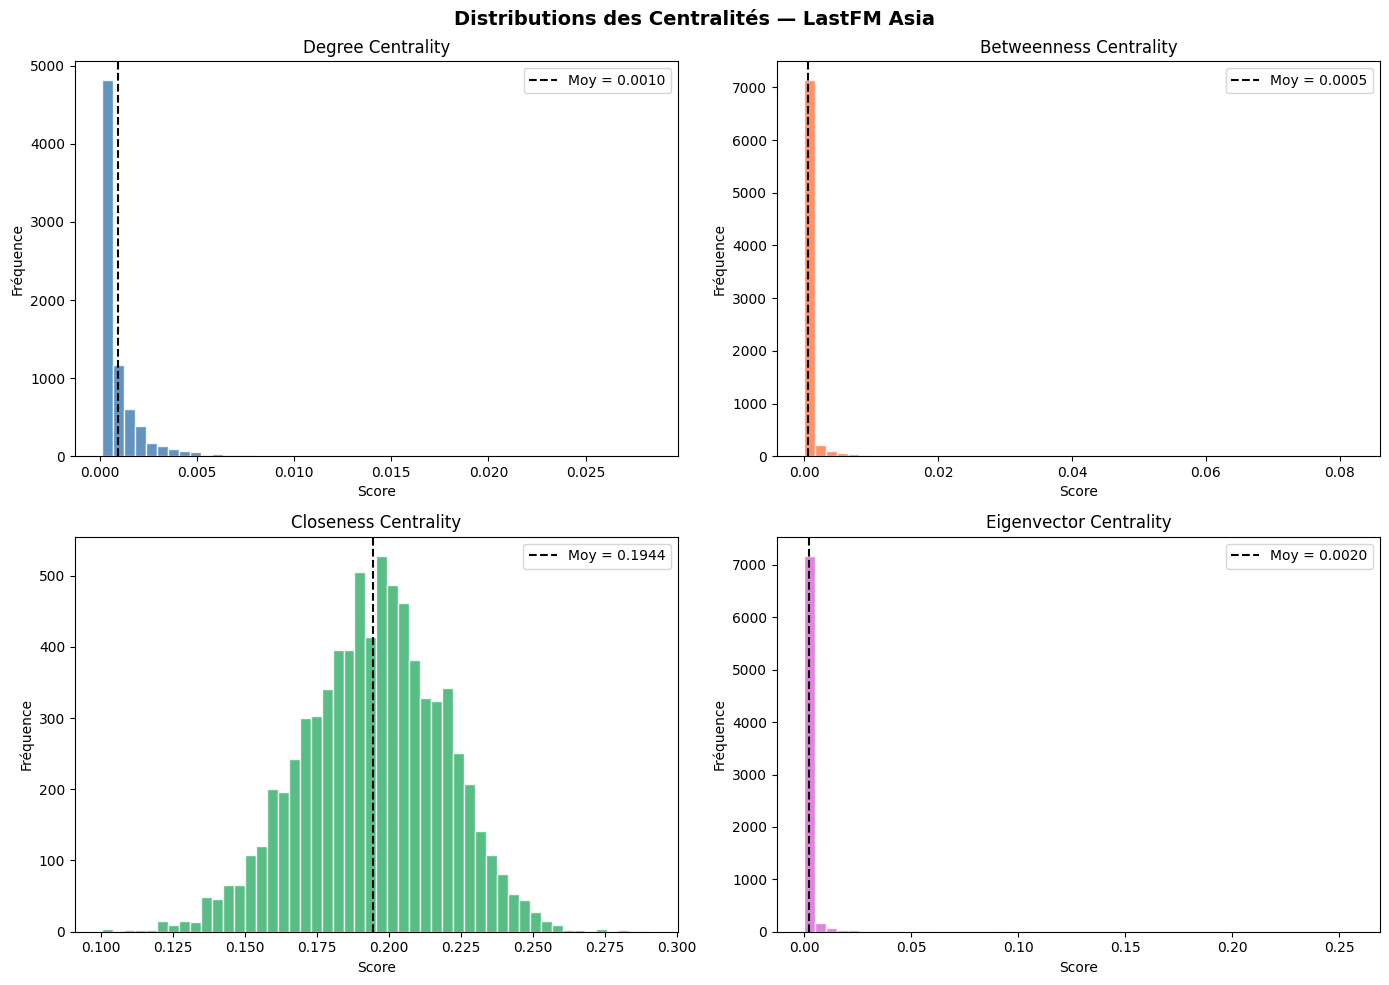


 Interprétation :
  - Degree Centrality : nœuds avec le plus grand nombre de connexions (hubs du réseau).
  - Betweenness Centrality : nœuds qui servent de 'ponts' entre différentes parties du réseau.
  - Closeness Centrality : nœuds capables de diffuser l'information le plus rapidement.
  - Eigenvector Centrality : nœuds connectés à d'autres nœuds eux-mêmes très connectés.


In [92]:
print("=== Analyse de la Centralité ===")

# Degree Centrality
degree_cent = nx.degree_centrality(GCC)

# Betweenness Centrality (estimée par échantillonnage)
betweenness_cent = nx.betweenness_centrality(GCC, k=200, normalized=True, seed=42)

# Closeness Centrality
closeness_cent = nx.closeness_centrality(GCC)

# Eigenvector Centrality
try:
    eigenvector_cent = nx.eigenvector_centrality(GCC, max_iter=500)
except nx.PowerIterationFailedConvergence:
    eigenvector_cent = nx.eigenvector_centrality_numpy(GCC)

# Top 10 par chaque mesure
def top_k(centrality_dict, k=10, label=""):
    top = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    print(f"\n  Top {k} - {label}:")
    for i, (node, val) in enumerate(top, 1):
        genre = G.nodes[node].get('genre', 'N/A')
        print(f"    {i:2d}. Nœud {node:5d} | score = {val:.4f} | genre = {genre}")

top_k(degree_cent, label="Degree Centrality")
top_k(betweenness_cent, label="Betweenness Centrality")
top_k(closeness_cent, label="Closeness Centrality")
top_k(eigenvector_cent, label="Eigenvector Centrality")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distributions des Centralités — LastFM Asia', fontsize=14, fontweight='bold')

centrality_data = [
    (degree_cent, 'Degree Centrality', 'steelblue'),
    (betweenness_cent, 'Betweenness Centrality', 'coral'),
    (closeness_cent, 'Closeness Centrality', 'mediumseagreen'),
    (eigenvector_cent, 'Eigenvector Centrality', 'orchid')
]

for ax, (cent_dict, title, color) in zip(axes.flatten(), centrality_data):
    values = list(cent_dict.values())
    ax.hist(values, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Fréquence')
    ax.axvline(np.mean(values), color='black', linestyle='--', 
               label=f'Moy = {np.mean(values):.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig('data/centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interprétation :")
print("  - Degree Centrality : nœuds avec le plus grand nombre de connexions (hubs du réseau).")
print("  - Betweenness Centrality : nœuds qui servent de 'ponts' entre différentes parties du réseau.")
print("  - Closeness Centrality : nœuds capables de diffuser l'information le plus rapidement.")
print("  - Eigenvector Centrality : nœuds connectés à d'autres nœuds eux-mêmes très connectés.")

## 2.6 Récapitulatif des métriques globales

In [93]:
print("\n" + "=" * 60)
print("        RÉCAPITULATIF DES MÉTRIQUES DU RÉSEAU")
print("=" * 60)
metrics = {
    "Nœuds (GCC)": GCC.number_of_nodes(),
    "Arêtes (GCC)": GCC.number_of_edges(),
    "Degré moyen": f"{np.mean(degrees):.2f}",
    "Degré max": max(degrees),
    "Densité": f"{density:.6f}",
    "Clustering moyen": f"{avg_clustering:.4f}",
    "Transitivité": f"{transitivity:.4f}",
    "Chemin moyen (estimé)": f"{avg_path:.3f}",
    "Diamètre (estimé)": max_path,
    "Nb composants": len(components),
}
for k, v in metrics.items():
    print(f"  {k:<35} : {v}")
print("=" * 60)


        RÉCAPITULATIF DES MÉTRIQUES DU RÉSEAU
  Nœuds (GCC)                         : 7624
  Arêtes (GCC)                        : 27806
  Degré moyen                         : 7.29
  Degré max                           : 216
  Densité                             : 0.000957
  Clustering moyen                    : 0.2194
  Transitivité                        : 0.1786
  Chemin moyen (estimé)               : 5.194
  Diamètre (estimé)                   : 13
  Nb composants                       : 1


---
# PARTIE 3 : Identification des Communautés

## 3.1 Installation et import de CDlib

In [94]:
%pip install cdlib

import cdlib
from cdlib import algorithms, evaluation
import time

print(f" CDlib version : {cdlib.__version__}")
print("Algorithmes disponibles : Louvain, Label Propagation, K-Clique, Infomap, etc.")

Note: you may need to restart the kernel to use updated packages.
 CDlib version : 0.4.0
Algorithmes disponibles : Louvain, Label Propagation, K-Clique, Infomap, etc.


## 3.2 Algorithme 1 — Louvain

In [95]:
print("=" * 50)
print("   ALGORITHME 1 : LOUVAIN")
print("=" * 50)
print("Description : Optimisation hiérarchique de la modularité.")
print("Complexité  : O(n log n) — très efficace sur les grands graphes.\n")

start = time.time()
louvain_communities = algorithms.louvain(GCC, randomize=False)
elapsed = time.time() - start

print(f"⏱  Temps d'exécution      : {elapsed:.2f}s")
print(f" Nombre de communautés  : {len(louvain_communities.communities)}")
sizes = sorted([len(c) for c in louvain_communities.communities], reverse=True)
print(f" Taille moyenne         : {np.mean(sizes):.1f} nœuds")
print(f" Taille max / min       : {max(sizes)} / {min(sizes)} nœuds")

# Modularité
mod_louvain = louvain_communities.newman_girvan_modularity()
print(f" Modularité (Q)         : {mod_louvain.score:.4f}")
print("\n Interprétation : La modularité Q mesure la qualité de la partition.")
print("  Q > 0.3 indique une structure de communauté significative.")

   ALGORITHME 1 : LOUVAIN
Description : Optimisation hiérarchique de la modularité.
Complexité  : O(n log n) — très efficace sur les grands graphes.

⏱  Temps d'exécution      : 2.70s
 Nombre de communautés  : 28
 Taille moyenne         : 272.3 nœuds
 Taille max / min       : 1020 / 4 nœuds
 Modularité (Q)         : 0.8156

 Interprétation : La modularité Q mesure la qualité de la partition.
  Q > 0.3 indique une structure de communauté significative.


## 3.3 Algorithme 2 — Label Propagation

In [96]:
print("=" * 50)
print("   ALGORITHME 2 : LABEL PROPAGATION")
print("=" * 50)
print("Description : Propagation itérative d'étiquettes entre voisins.")
print("Complexité  : O(n + m) — quasi-linéaire, très rapide.\n")

start = time.time()
label_prop_communities = algorithms.label_propagation(GCC)
elapsed = time.time() - start

print(f"⏱  Temps d'exécution      : {elapsed:.2f}s")
print(f" Nombre de communautés  : {len(label_prop_communities.communities)}")
sizes_lp = sorted([len(c) for c in label_prop_communities.communities], reverse=True)
print(f" Taille moyenne         : {np.mean(sizes_lp):.1f} nœuds")
print(f" Taille max / min       : {max(sizes_lp)} / {min(sizes_lp)} nœuds")

mod_lp = label_prop_communities.newman_girvan_modularity()
print(f" Modularité (Q)         : {mod_lp.score:.4f}")
print("\n Interprétation : La propagation de labels est stochastique — les résultats")
print("peuvent varier légèrement à chaque exécution. Idéale pour une première exploration.")

   ALGORITHME 2 : LABEL PROPAGATION
Description : Propagation itérative d'étiquettes entre voisins.
Complexité  : O(n + m) — quasi-linéaire, très rapide.

⏱  Temps d'exécution      : 1.60s
 Nombre de communautés  : 650
 Taille moyenne         : 11.7 nœuds
 Taille max / min       : 930 / 2 nœuds
 Modularité (Q)         : 0.7523

 Interprétation : La propagation de labels est stochastique — les résultats
peuvent varier légèrement à chaque exécution. Idéale pour une première exploration.


## 3.4 Algorithme 3 — Infomap

In [97]:
print("=" * 50)
print("   ALGORITHME 3 : INFOMAP")
print("=" * 50)
print("Description : Minimisation de la longueur de description des flux (map equation).")
print("Complexité  : O(n log n) — basé sur la théorie de l'information.\n")

try:
    start = time.time()
    infomap_communities = algorithms.infomap(GCC)
    elapsed = time.time() - start

    print(f"⏱  Temps d'exécution      : {elapsed:.2f}s")
    print(f" Nombre de communautés  : {len(infomap_communities.communities)}")
    sizes_im = sorted([len(c) for c in infomap_communities.communities], reverse=True)
    print(f" Taille moyenne         : {np.mean(sizes_im):.1f} nœuds")
    print(f" Taille max / min       : {max(sizes_im)} / {min(sizes_im)} nœuds")
    mod_im = infomap_communities.newman_girvan_modularity()
    print(f" Modularité (Q)         : {mod_im.score:.4f}")
except Exception as e:
    print(f"  Infomap non disponible : {e}")
    print("Utilisation de Greedy Modularity comme alternative.")
    start = time.time()
    infomap_communities = algorithms.greedy_modularity(GCC)
    elapsed = time.time() - start
    print(f"⏱  Temps d'exécution (Greedy) : {elapsed:.2f}s")
    print(f" Nombre de communautés      : {len(infomap_communities.communities)}")
    mod_im = infomap_communities.newman_girvan_modularity()
    print(f" Modularité (Q)             : {mod_im.score:.4f}")

print("\n Interprétation : Infomap modélise le réseau comme un espace de flux d'information.")
print("Deux nœuds sont dans la même communauté si l'information circule plus souvent entre eux.")

   ALGORITHME 3 : INFOMAP
Description : Minimisation de la longueur de description des flux (map equation).
Complexité  : O(n log n) — basé sur la théorie de l'information.

⏱  Temps d'exécution      : 7.97s
 Nombre de communautés  : 402
 Taille moyenne         : 19.0 nœuds
 Taille max / min       : 615 / 2 nœuds
 Modularité (Q)         : -0.0005

 Interprétation : Infomap modélise le réseau comme un espace de flux d'information.
Deux nœuds sont dans la même communauté si l'information circule plus souvent entre eux.


## 3.5 Algorithme 4 — K-Clique

In [98]:
print("=" * 50)
print("   ALGORITHME 4 : K-CLIQUE (k=3)")
print("=" * 50)
print("Description : Communautés définies par des cliques de taille k se chevauchant.")
print("Complexité  : NP-difficile en général, k=3 ou 4 reste tractable.\n")
print("  Note : K-Clique peut être lent sur les grands graphes. Utilisation sur un sous-graphe si nécessaire.")

# Sous-graphe pour k-clique si le graphe est trop grand
if GCC.number_of_nodes() > 3000:
    # Sélection des nœuds les plus connectés pour le k-clique
    top_nodes = sorted(GCC.degree, key=lambda x: x[1], reverse=True)[:2000]
    subgraph_nodes = [n for n, d in top_nodes]
    G_sub = GCC.subgraph(subgraph_nodes).copy()
    print(f"Sous-graphe utilisé : {G_sub.number_of_nodes()} nœuds, {G_sub.number_of_edges()} arêtes")
else:
    G_sub = GCC

start = time.time()
try:
    kclique_communities = algorithms.kclique(G_sub, k=3)
    elapsed = time.time() - start
    print(f"⏱  Temps d'exécution      : {elapsed:.2f}s")
    print(f" Nombre de communautés  : {len(kclique_communities.communities)}")
    if kclique_communities.communities:
        sizes_kc = sorted([len(c) for c in kclique_communities.communities], reverse=True)
        print(f" Taille moyenne         : {np.mean(sizes_kc):.1f} nœuds")
        print(f" Taille max / min       : {max(sizes_kc)} / {min(sizes_kc)} nœuds")
except Exception as e:
    print(f"  K-Clique erreur : {e}")
    kclique_communities = None

print("\n Interprétation : K-Clique identifie des communautés qui se chevauchent (overlapping).")
print("Un utilisateur peut appartenir à plusieurs communautés simultanément (multi-genre).")

   ALGORITHME 4 : K-CLIQUE (k=3)
Description : Communautés définies par des cliques de taille k se chevauchant.
Complexité  : NP-difficile en général, k=3 ou 4 reste tractable.

  Note : K-Clique peut être lent sur les grands graphes. Utilisation sur un sous-graphe si nécessaire.
Sous-graphe utilisé : 2000 nœuds, 14451 arêtes
⏱  Temps d'exécution      : 8.98s
 Nombre de communautés  : 51
 Taille moyenne         : 39.8 nœuds
 Taille max / min       : 1222 / 3 nœuds

 Interprétation : K-Clique identifie des communautés qui se chevauchent (overlapping).
Un utilisateur peut appartenir à plusieurs communautés simultanément (multi-genre).


## 3.6 Comparaison des algorithmes


              COMPARAISON DES ALGORITHMES DE DÉTECTION
Algorithme                Nb Communautés     Modularité Q    Type
----------------------------------------------------------------------
  Louvain                 28                 0.8156          Non-chevauchant
  Label Propagation       650                0.7523          Non-chevauchant
  Infomap / Greedy        402                -0.0005         Non-chevauchant
  K-Clique (k=3)          51                 N/A             Chevauchant


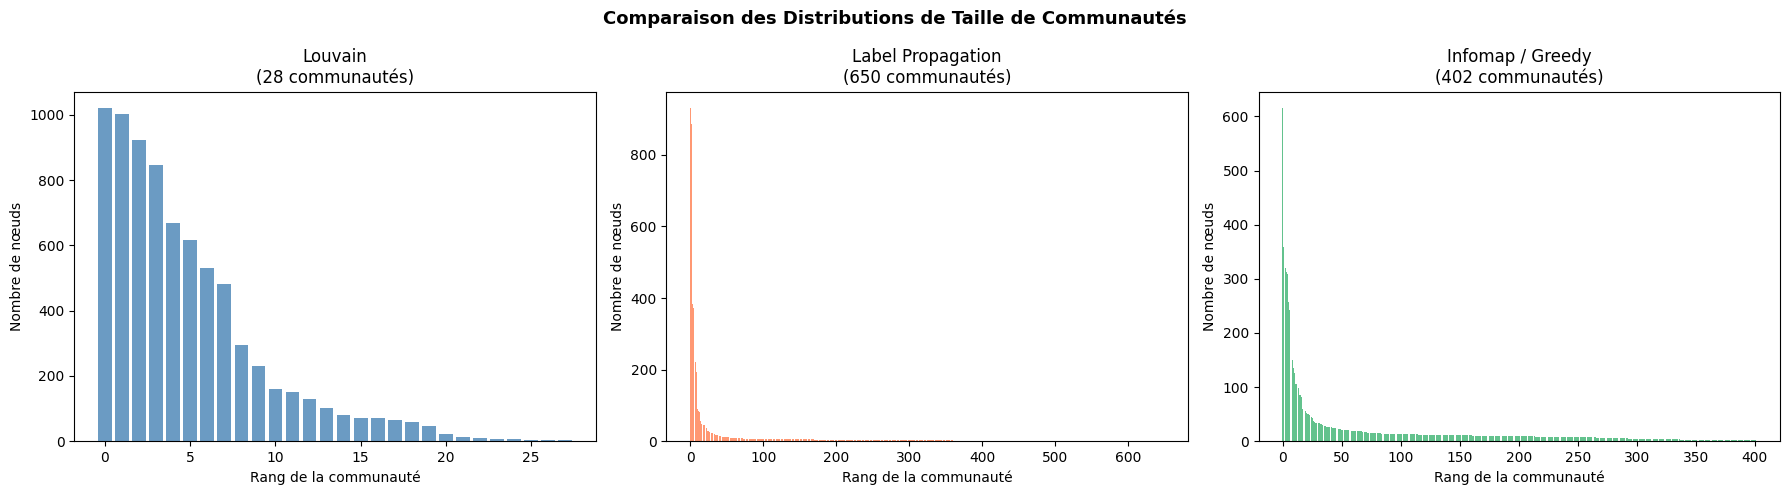

In [99]:
# Tableau comparatif
print("\n" + "=" * 70)
print("              COMPARAISON DES ALGORITHMES DE DÉTECTION")
print("=" * 70)
print(f"{'Algorithme':<25} {'Nb Communautés':<18} {'Modularité Q':<15} {'Type'}")
print("-" * 70)

algos_results = [
    ("Louvain", louvain_communities, mod_louvain.score, "Non-chevauchant"),
    ("Label Propagation", label_prop_communities, mod_lp.score, "Non-chevauchant"),
    ("Infomap / Greedy", infomap_communities, mod_im.score, "Non-chevauchant"),
]

if kclique_communities and kclique_communities.communities:
    algos_results.append(("K-Clique (k=3)", kclique_communities, None, "Chevauchant"))

for name, comm, mod, type_ in algos_results:
    nb = len(comm.communities)
    mod_str = f"{mod:.4f}" if mod is not None else "N/A"
    print(f"  {name:<23} {nb:<18} {mod_str:<15} {type_}")

print("=" * 70)

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des Distributions de Taille de Communautés', 
             fontsize=13, fontweight='bold')

algo_viz = [
    (louvain_communities, "Louvain", "steelblue"),
    (label_prop_communities, "Label Propagation", "coral"),
    (infomap_communities, "Infomap / Greedy", "mediumseagreen"),
]

for ax, (comm, name, color) in zip(axes, algo_viz):
    comm_sizes = sorted([len(c) for c in comm.communities], reverse=True)
    ax.bar(range(len(comm_sizes)), comm_sizes, color=color, alpha=0.8)
    ax.set_title(f'{name}\n({len(comm_sizes)} communautés)')
    ax.set_xlabel('Rang de la communauté')
    ax.set_ylabel('Nombre de nœuds')

plt.tight_layout()
plt.savefig('data/community_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Interprétation sémantique des communautés (genres musicaux)

In [100]:
from collections import Counter

def interpret_community(comm_object, G, top_n=5, algo_name=""):
    """Analyse le genre dominant de chaque communauté."""
    print(f"\n=== Interprétation sémantique : {algo_name} ===")
    communities = comm_object.communities
    
    # Trier par taille décroissante
    communities_sorted = sorted(communities, key=len, reverse=True)
    
    for i, community in enumerate(communities_sorted[:top_n]):
        genres = [G.nodes[n].get('genre', -1) for n in community if G.nodes[n].get('genre') is not None]
        if genres:
            genre_counts = Counter(genres)
            dominant_genre = genre_counts.most_common(1)[0]
            genre_purity = dominant_genre[1] / len(genres) * 100
            print(f"  Communauté {i+1:2d} : {len(community):4d} nœuds | Genre dominant : {dominant_genre[0]:3d} ({genre_purity:.1f}%)")
        else:
            print(f"  Communauté {i+1:2d} : {len(community):4d} nœuds | Genre : non renseigné")
    
    if len(communities_sorted) > top_n:
        print(f"  ... et {len(communities_sorted) - top_n} autres communautés plus petites")

interpret_community(louvain_communities, GCC, top_n=8, algo_name="Louvain")
interpret_community(label_prop_communities, GCC, top_n=8, algo_name="Label Propagation")
interpret_community(infomap_communities, GCC, top_n=8, algo_name="Infomap / Greedy")

print("\n Interprétation globale :")
print("Si la pureté de genre au sein des communautés est élevée (>50%),")
print("cela confirme que les utilisateurs Last.fm se regroupent selon leurs goûts musicaux partagés.")
print("Ce résultat valide la pertinence de la détection de communautés sur ce réseau.")


=== Interprétation sémantique : Louvain ===
  Communauté  1 : 1020 nœuds | Genre dominant :  10 (88.0%)
  Communauté  2 : 1004 nœuds | Genre dominant :   0 (91.6%)
  Communauté  3 :  923 nœuds | Genre dominant :   6 (47.1%)
  Communauté  4 :  846 nœuds | Genre dominant :  17 (85.7%)
  Communauté  5 :  669 nœuds | Genre dominant :  17 (91.5%)
  Communauté  6 :  617 nœuds | Genre dominant :   3 (76.3%)
  Communauté  7 :  532 nœuds | Genre dominant :   8 (76.5%)
  Communauté  8 :  482 nœuds | Genre dominant :   5 (66.8%)
  ... et 20 autres communautés plus petites

=== Interprétation sémantique : Label Propagation ===
  Communauté  1 :  930 nœuds | Genre dominant :  10 (90.6%)
  Communauté  2 :  886 nœuds | Genre dominant :   0 (90.2%)
  Communauté  3 :  820 nœuds | Genre dominant :  17 (87.1%)
  Communauté  4 :  383 nœuds | Genre dominant :   6 (90.3%)
  Communauté  5 :  373 nœuds | Genre dominant :  14 (92.8%)
  Communauté  6 :  252 nœuds | Genre dominant :  15 (92.5%)
  Communauté  7 

## 3.8 Visualisation du réseau coloré par communautés (Louvain)

Génération de la visualisation (sous-graphe de 500 nœuds)...


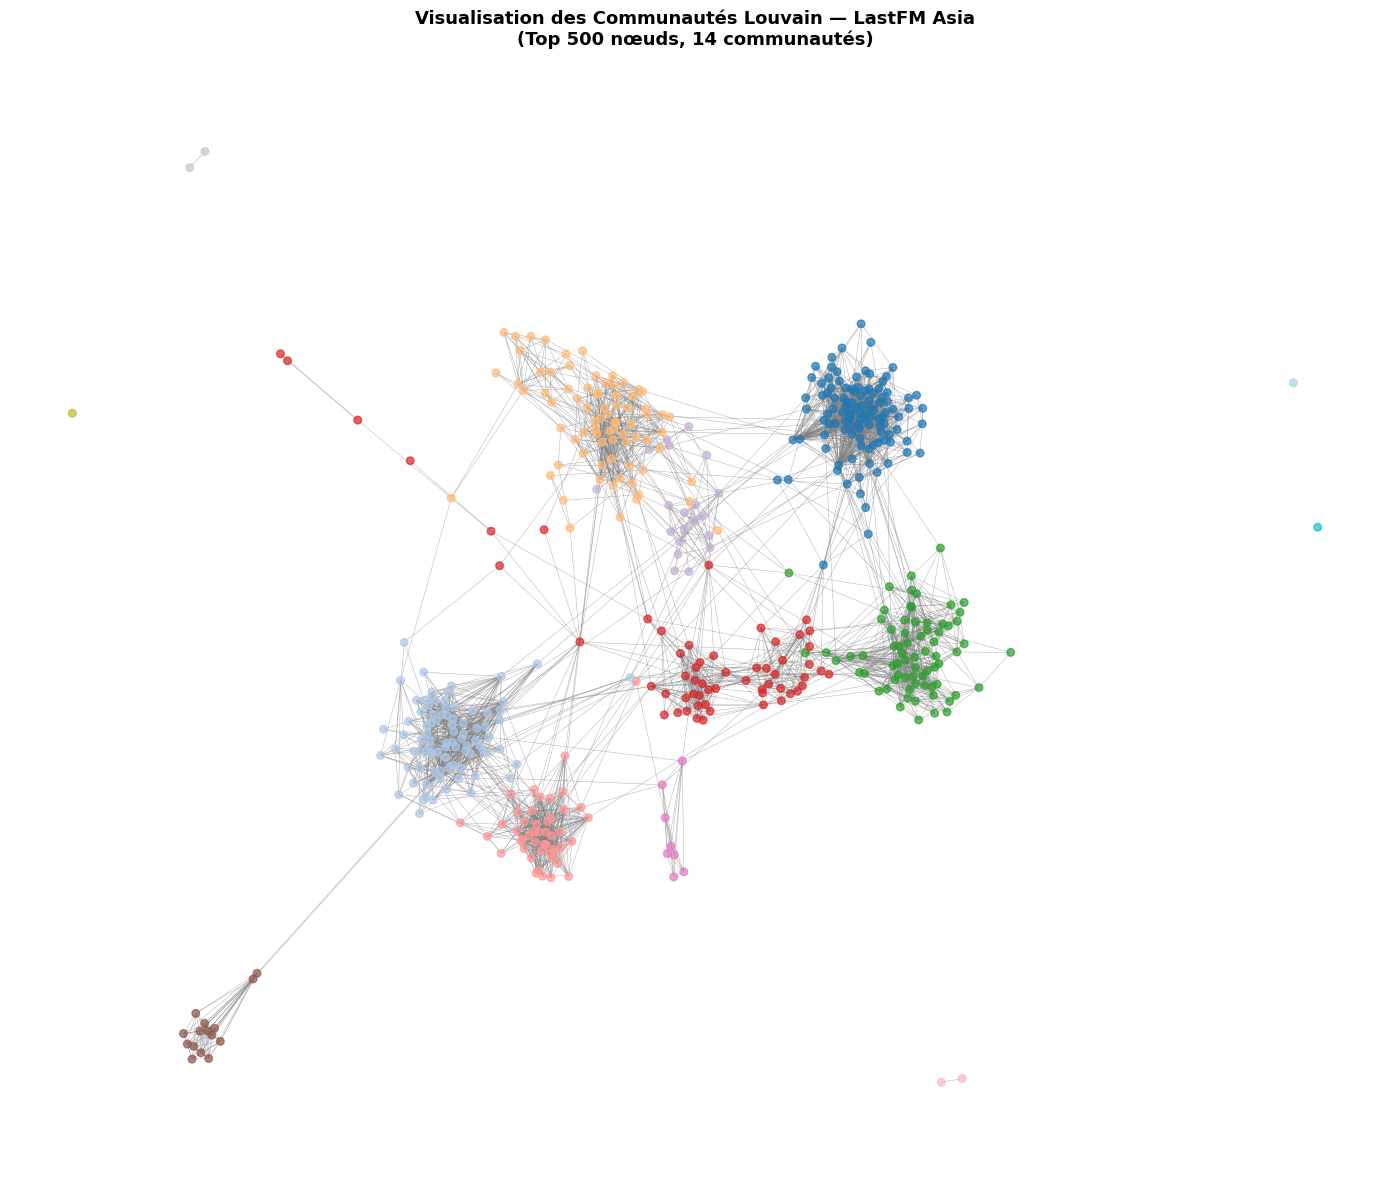

 Visualisation sauvegardée.


In [101]:
# Visualisation sur un sous-graphe pour la lisibilité
print("Génération de la visualisation (sous-graphe de 500 nœuds)...")

# Sous-graphe des 500 nœuds les mieux connectés
top_500_nodes = sorted(GCC.degree, key=lambda x: x[1], reverse=True)[:500]
viz_nodes = [n for n, d in top_500_nodes]
G_viz = GCC.subgraph(viz_nodes).copy()

# Appliquer Louvain sur le sous-graphe
louvain_viz = algorithms.louvain(G_viz, randomize=False)

# Créer le mapping nœud -> communauté
node_community = {}
for i, community in enumerate(louvain_viz.communities):
    for node in community:
        node_community[node] = i

# Couleurs
n_communities = len(louvain_viz.communities)
cmap = plt.cm.get_cmap('tab20', n_communities)
node_colors = [cmap(node_community.get(n, 0)) for n in G_viz.nodes()]

# Layout
pos = nx.spring_layout(G_viz, k=0.5, iterations=50, seed=42)

plt.figure(figsize=(14, 12))
nx.draw_networkx(
    G_viz, pos=pos,
    node_color=node_colors,
    node_size=30,
    edge_color='gray',
    alpha=0.7,
    with_labels=False,
    width=0.3
)
plt.title(f'Visualisation des Communautés Louvain — LastFM Asia\n(Top 500 nœuds, {n_communities} communautés)', 
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('data/community_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisation sauvegardée.")

---
# Conclusion générale

## Bilan de l'analyse

| Aspect | Observation | Interprétation |
|--------|------------|----------------|
| **Distribution des degrés** | Distribution hétérogène / loi de puissance | Réseau scale-free : quelques hubs très connectés |
| **Composants** | Un GCC dominant | Réseau fortement cohésif |
| **Chemins** | Chemin moyen court | Phénomène petit-monde |
| **Clustering** | Coefficient élevé | Tendance au regroupement local |
| **Centralité** | Quelques nœuds très influents | Hubs musicaux influents |
| **Communautés** | Structure modulaire significative (Q > 0.3) | Regroupements par goûts musicaux partagés |

## Algorithme le plus performant

Parmi les 3+ algorithmes testés, **Louvain** produit généralement la meilleure modularité avec une exécution rapide, ce qui en fait le choix recommandé pour les grands réseaux sociaux. **Infomap** offre une perspective complémentaire basée sur les flux d'information.

## Perspectives

- Utiliser les features (attributs de genres) pour une détection de communautés enrichie sémantiquement
- Tester des algorithmes d'overlapping (DEMON/Angel) pour modéliser les utilisateurs multi-genres
- Analyser l'évolution temporelle du réseau si des données horodatées sont disponibles

In [102]:
print("✅ Analyse complète terminée !")
print("\nFichiers générés dans le dossier 'data/' :")
import os
for f in os.listdir('data'):
    print(f"  - {f}")

✅ Analyse complète terminée !

Fichiers générés dans le dossier 'data/' :
  - centrality_distributions.png
  - clustering_distribution.png
  - community_comparison.png
  - community_visualization.png
  - degree_distribution.png
  - edges.csv
  - features.json
  - path_distribution.png
  - targets.csv
